In [1]:
import numpy as np
import pandas as pd
import mat73
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 12

In [2]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    '/Users/skax/skala/ess-battery-project/data'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : /Users/skax/skala/ess-battery-project/data
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함

In [3]:
# .mat 파일 로더
def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print(f"{os.path.basename(path)} -> 로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print(f"{os.path.basename(path)} -> 로드 완료 (MATLAB v7.2 이하 형식)")
    return data

# 파일 순서 기준으로 batch1, batch2, batch3 지정
batch_map = {
    "batch1": files[0],
    "batch2": files[1],
    "batch3": files[2],
}

print("\n배치 파일 매핑:")
for batch_name, file_name in batch_map.items():
    print(f"  {batch_name} = {file_name}")

# 각 batch 로드
print("\n=== Batch 1 로딩 ===")
batch1_path = os.path.join(DATA_DIR, batch_map["batch1"])
batch1 = load_mat(batch1_path)

print("\n=== Batch 2 로딩 ===")
batch2_path = os.path.join(DATA_DIR, batch_map["batch2"])
batch2 = load_mat(batch2_path)

print("\n=== Batch 3 로딩 ===")
batch3_path = os.path.join(DATA_DIR, batch_map["batch3"])
batch3 = load_mat(batch3_path)

# 최상위 키 확인
print("\n[Batch 1 최상위 키]")
print(list(batch1.keys()))

print("\n[Batch 2 최상위 키]")
print(list(batch2.keys()))

print("\n[Batch 3 최상위 키]")
print(list(batch3.keys()))

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro


배치 파일 매핑:
  batch1 = 2017-05-12_batchdata_updated_struct_errorcorrect.mat
  batch2 = 2018-02-20_batchdata_updated_struct_errorcorrect.mat
  batch3 = 2018-04-12_batchdata_updated_struct_errorcorrect.mat

=== Batch 1 로딩 ===


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

2017-05-12_batchdata_updated_struct_errorcorrect.mat -> 로드 완료 (MATLAB v7.3 / HDF5 형식)

=== Batch 2 로딩 ===


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

2018-02-20_batchdata_updated_struct_errorcorrect.mat -> 로드 완료 (MATLAB v7.3 / HDF5 형식)

=== Batch 3 로딩 ===
2018-04-12_batchdata_updated_struct_errorcorrect.mat -> 로드 완료 (MATLAB v7.3 / HDF5 형식)

[Batch 1 최상위 키]
['batch', 'batch_date']

[Batch 2 최상위 키]
['batch', 'batch_date']

[Batch 3 최상위 키]
['batch', 'batch_date']


In [4]:
def extract_batch(mat, batch_name=""):
    batch = mat['batch']

    # mat73 → dict of list → list of dict 변환
    if isinstance(batch, dict):
        keys = list(batch.keys())
        n_cells = len(batch[keys[0]])
        batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
        print(f"{batch_name} → mat73 형식 변환 완료")

    print(f"\n[{batch_name}]")
    print(f"배터리 셀 수    : {len(batch)}")
    print(f"타입            : {type(batch)}")
    print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

    return batch

In [5]:
batch1_cells = extract_batch(batch1, "Batch1")
batch2_cells = extract_batch(batch2, "Batch2")
batch3_cells = extract_batch(batch3, "Batch3")

Batch1 → mat73 형식 변환 완료

[Batch1]
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
Batch2 → mat73 형식 변환 완료

[Batch2]
배터리 셀 수    : 47
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
Batch3 → mat73 형식 변환 완료

[Batch3]
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
batches = {
    "Batch1": batch1_cells,
    "Batch2": batch2_cells,
    "Batch3": batch3_cells,
}

for batch_name, batch in batches.items():
    print("\n" + "=" * 60)
    print(f"{batch_name} - 첫 번째 셀 구조")
    print("=" * 60)

    cell0 = batch[0]

    for key, val in cell0.items():
        if isinstance(val, np.ndarray):
            print(f"  {key:25s} | ndarray  | shape={val.shape}")
        elif isinstance(val, dict):
            print(f"  {key:25s} | dict     | keys={list(val.keys())}")
        else:
            print(f"  {key:25s} | {type(val).__name__:8s} | {val}")


Batch1 - 첫 번째 셀 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

Batch2 - 첫 번째 셀 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 5_2C_58PER_4C
  policy_readable           | str      | 5.

In [7]:
import numpy as np

batches = {
    "Batch1": batch1_cells,
    "Batch2": batch2_cells,
    "Batch3": batch3_cells,
}

for batch_name, batch in batches.items():
    print("\n" + "=" * 60)
    print(f"{batch_name} - cycles 구조 확인 (cell[0])")
    print("=" * 60)

    cell0 = batch[0]
    cycles_raw = cell0['cycles']

    # mat73 → dict of lists → list of dict 변환
    if isinstance(cycles_raw, dict):
        keys = list(cycles_raw.keys())
        n_cycles = len(cycles_raw[keys[0]])
        cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
        print("mat73 형식 → list of dict 변환 완료")
    else:
        cycles = cycles_raw

    print(f"총 사이클 수 : {len(cycles)}")

    print(f"\n사이클[0] 내 변수 목록 :")
    for key, val in cycles[0].items():
        if isinstance(val, np.ndarray):
            print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
        else:
            print(f"  {key:15s} | {type(val).__name__:8s} | {val}")


Batch1 - cycles 구조 확인 (cell[0])
mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None

Batch2 - cycles 구조 확인 (cell[0])
mat73 형식 → list of dict 변환 완료
총 사이클 수 : 496

사이클[0] 내 변수 목록 :
  I               | ndarray | shape=(1042,) | dtype=float64
  Qc              | ndarray | shape=(1042,) | dtype=float64
  Qd              | ndarray | shape=(1042,) | dtype=float64
  Qdlin           | ndarray | shape=(1000,) | dtype=float64
  T               | ndarray | shape=(1042,) | dtype=float64
  Tdlin           | ndarray | shape=(1000,) | dtype=float64
  V               | ndarray | shape=(1042,) | dtype=float64
  discharge_dQdV  | ndarray | shape=(1000,) | dtype=float64
  t  

## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [8]:
import pandas as pd
import numpy as np

def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d


def extract_summary(batch, batch_name="batch"):
    """배터리 셀별 summary 데이터를 cell 기준 1행 DataFrame으로 변환"""
    records = []

    for i, cell in enumerate(batch):
        summary = cell["summary"]

        if isinstance(summary, dict):
            qd   = np.array(summary["QDischarge"], dtype=float)
            qc   = np.array(summary["QCharge"], dtype=float)
            ir   = np.array(summary["IR"], dtype=float)
            tmax = np.array(summary["Tmax"], dtype=float)
            tavg = np.array(summary["Tavg"], dtype=float)
            tmin = np.array(summary["Tmin"], dtype=float)
            ct   = np.array(summary["chargetime"], dtype=float)
        else:
            qd   = np.array(summary["QDischarge"], dtype=float)
            qc   = np.array(summary["QCharge"], dtype=float)
            ir   = np.array(summary["IR"], dtype=float)
            tmax = np.array(summary["Tmax"], dtype=float)
            tavg = np.array(summary["Tavg"], dtype=float)
            tmin = np.array(summary["Tmin"], dtype=float)
            ct   = np.array(summary["chargetime"], dtype=float)

        # cycle_life 안전 처리
        cl_raw = cell.get("cycle_life")
        if isinstance(cl_raw, np.ndarray):
            cl_raw = cl_raw.item()

        if cl_raw is None or (isinstance(cl_raw, float) and np.isnan(cl_raw)):
            cycle_life = np.nan
        else:
            cycle_life = cl_raw

        policy = str(cell.get("policy_readable") or cell.get("policy") or "unknown")

        records.append({
            "batch": batch_name,
            "cell_id": i,
            "cycle_life": cycle_life,
            "charging_policy": policy,

            # 대표 통계값
            "n_cycles": len(qd),

            "QD_mean": np.nanmean(qd),
            "QD_std": np.nanstd(qd),
            "QD_min": np.nanmin(qd),
            "QD_max": np.nanmax(qd),
            "QD_last": qd[-1] if len(qd) > 0 else np.nan,

            "QC_mean": np.nanmean(qc),
            "QC_std": np.nanstd(qc),
            "QC_min": np.nanmin(qc),
            "QC_max": np.nanmax(qc),
            "QC_last": qc[-1] if len(qc) > 0 else np.nan,

            "IR_mean": np.nanmean(ir),
            "IR_std": np.nanstd(ir),
            "IR_min": np.nanmin(ir),
            "IR_max": np.nanmax(ir),
            "IR_last": ir[-1] if len(ir) > 0 else np.nan,

            "Tmax_mean": np.nanmean(tmax),
            "Tmax_std": np.nanstd(tmax),
            "Tmax_min": np.nanmin(tmax),
            "Tmax_max": np.nanmax(tmax),
            "Tmax_last": tmax[-1] if len(tmax) > 0 else np.nan,

            "Tavg_mean": np.nanmean(tavg),
            "Tavg_std": np.nanstd(tavg),
            "Tavg_min": np.nanmin(tavg),
            "Tavg_max": np.nanmax(tavg),
            "Tavg_last": tavg[-1] if len(tavg) > 0 else np.nan,

            "Tmin_mean": np.nanmean(tmin),
            "Tmin_std": np.nanstd(tmin),
            "Tmin_min": np.nanmin(tmin),
            "Tmin_max": np.nanmax(tmin),
            "Tmin_last": tmin[-1] if len(tmin) > 0 else np.nan,

            "chargetime_mean": np.nanmean(ct),
            "chargetime_std": np.nanstd(ct),
            "chargetime_min": np.nanmin(ct),
            "chargetime_max": np.nanmax(ct),
            "chargetime_last": ct[-1] if len(ct) > 0 else np.nan,
        })

    df = pd.DataFrame(records)

    numeric_cols = [col for col in df.columns if col not in ["batch", "charging_policy"]]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [9]:
df_batch1 = extract_summary(batch1_cells, batch_name="batch1")
df_batch2 = extract_summary(batch2_cells, batch_name="batch2")
df_batch3 = extract_summary(batch3_cells, batch_name="batch3")

In [10]:
print("Batch1 shape:", df_batch1.shape)
print("Batch2 shape:", df_batch2.shape)
print("Batch3 shape:", df_batch3.shape)

display(df_batch1.head())
display(df_batch2.head())
display(df_batch3.head())

Batch1 shape: (46, 40)
Batch2 shape: (47, 40)
Batch3 shape: (46, 40)


,batch,cell_id,cycle_life,charging_policy,n_cycles,QD_mean,QD_std,QD_min,QD_max,QD_last,...,Tmin_mean,Tmin_std,Tmin_min,Tmin_max,Tmin_last,chargetime_mean,chargetime_std,chargetime_min,chargetime_max,chargetime_last
0,batch1,0,1190.0,3.6C(80%)-3.6C,1189,1.053274,0.037082,0.0,1.539054,1.026210,...,29.457982,1.355524,0.0,32.662971,29.681129,13.408651,0.398487,0.0,13.958458,13.425712
1,batch1,1,1179.0,3.6C(80%)-3.6C,1178,1.062865,0.033618,0.0,1.084590,1.038225,...,29.653546,1.329063,0.0,32.833340,29.990858,13.370045,0.392977,0.0,14.342623,13.341427
2,batch1,2,1177.0,3.6C(80%)-3.6C,1176,1.067557,0.033720,0.0,1.088054,1.043279,...,29.720662,1.298357,0.0,32.887569,29.918173,13.367353,0.393204,0.0,14.342297,13.341217
3,batch1,3,1226.0,4C(80%)-4C,1225,1.056266,0.040472,0.0,1.086253,0.970921,...,29.554381,1.536162,0.0,33.075611,29.645372,12.279253,7.611266,0.0,278.281358,12.258032
4,batch1,4,1227.0,4C(80%)-4C,1226,1.060178,0.034863,0.0,1.084317,1.021960,...,29.821340,1.519254,0.0,33.573570,29.698412,12.041656,0.347116,0.0,12.187848,12.178558


,batch,cell_id,cycle_life,charging_policy,n_cycles,QD_mean,QD_std,QD_min,QD_max,QD_last,...,Tmin_mean,Tmin_std,Tmin_min,Tmin_max,Tmin_last,chargetime_mean,chargetime_std,chargetime_min,chargetime_max,chargetime_last
0,batch2,0,477.0,5.2C(58%)-4C,496,1.064247,0.068916,0.826613,1.116355,0.826613,...,30.220363,0.451233,28.851412,31.131500,30.102110,11.118243,3.569933,10.092157,38.693195,20.0
1,batch2,1,491.0,5.6C(26%)-4.5C,513,1.049764,0.069470,0.828482,1.109358,0.828482,...,30.831458,0.298418,29.748539,31.534011,31.136780,11.040925,2.740867,10.025908,34.803228,20.0
2,batch2,2,424.0,5.2C(50%)-4.25C,439,1.041175,0.055941,0.827009,1.080958,0.827009,...,30.867839,0.302292,30.181173,32.057763,30.973535,10.817823,2.532442,10.103680,33.103078,20.0
3,batch2,3,499.0,4.65C(44%)-5C,517,1.054593,0.065919,0.825510,1.108017,0.825510,...,30.744209,0.304330,29.998203,31.542208,30.108393,11.043497,2.671833,10.171903,35.356417,20.0
4,batch2,4,444.0,4.65C(69%)-6C,464,1.035968,0.064221,0.827127,1.090851,0.827127,...,30.183687,0.260399,29.671949,31.121681,30.069622,11.354740,2.534084,10.149520,34.528185,20.0


,batch,cell_id,cycle_life,charging_policy,n_cycles,QD_mean,QD_std,QD_min,QD_max,QD_last,...,Tmin_mean,Tmin_std,Tmin_min,Tmin_max,Tmin_last,chargetime_mean,chargetime_std,chargetime_min,chargetime_max,chargetime_last
0,batch3,0,1009.0,5C(67%)-4C-newstructure,1008,1.037084,0.040273,0.880433,1.071371,0.880433,...,31.622150,0.409650,30.613684,32.458736,31.365874,10.155437,0.502752,10.040100,16.364433,16.364433
1,batch3,1,1063.0,5.3C(54%)-4C-newstructure,1062,1.032149,0.042083,0.880273,1.068740,0.880273,...,32.586425,0.498795,31.221146,33.495445,33.063055,10.142999,0.470738,10.024057,16.284175,16.284175
2,batch3,2,1267.0,5.6C(19%)-4.6C-newstructure,1266,1.021500,0.044437,0.880131,1.063214,0.880131,...,34.078277,0.902776,31.907530,36.691219,35.380840,10.197322,0.554248,10.040880,17.144188,17.144188
3,batch3,3,1115.0,5.6C(36%)-4.3C-newstructure,1114,1.029005,0.041890,0.880584,1.065534,0.880584,...,33.520140,0.664970,31.780437,34.944206,33.982616,10.187437,0.568591,10.039438,16.898287,16.898287
4,batch3,4,1048.0,5.6C(19%)-4.6C-newstructure,1047,1.035761,0.046478,0.880015,1.075265,0.880015,...,31.930126,0.429543,30.863256,32.822717,31.608629,10.238485,0.659003,10.041718,17.548647,17.548647


In [11]:
df_batch1.describe().round(3)

,cell_id,cycle_life,n_cycles,QD_mean,QD_std,QD_min,QD_max,QD_last,QC_mean,QC_std,...,Tmin_mean,Tmin_std,Tmin_min,Tmin_max,Tmin_last,chargetime_mean,chargetime_std,chargetime_min,chargetime_max,chargetime_last
count,46.000,46.000,46.000,46.000,46.000,46.0,46.000,46.000,46.000,46.000,...,46.000,46.000,46.0,46.000,46.000,46.000,46.000,46.0,46.000,46.000
mean,22.500,844.717,843.717,1.044,0.059,0.0,1.133,0.903,1.044,0.060,...,30.644,1.498,0.0,33.915,30.869,11.389,2.396,0.0,63.201,20.123
std,13.423,184.629,184.629,0.011,0.011,0.0,0.272,0.047,0.011,0.017,...,0.471,0.112,0.0,0.504,1.002,0.874,3.566,0.0,115.048,4.467
min,0.000,534.000,533.000,1.007,0.034,0.0,1.063,0.880,1.006,0.034,...,29.458,1.298,0.0,32.663,29.064,9.600,0.347,0.0,11.624,11.532
25%,11.250,703.250,702.250,1.039,0.058,0.0,1.082,0.880,1.039,0.057,...,30.522,1.415,0.0,33.712,30.043,10.726,0.926,0.0,20.042,19.422
50%,22.500,858.500,857.500,1.042,0.061,0.0,1.084,0.881,1.043,0.061,...,30.711,1.496,0.0,34.038,30.637,11.435,1.234,0.0,22.250,21.662
75%,33.750,914.250,913.250,1.050,0.064,0.0,1.088,0.883,1.050,0.063,...,30.943,1.563,0.0,34.225,31.516,11.807,1.570,0.0,24.457,23.095
max,45.000,1227.000,1226.000,1.068,0.092,0.0,2.884,1.043,1.067,0.154,...,31.434,1.748,0.0,34.851,33.618,13.409,15.283,0.0,419.873,25.691


In [12]:
df_batch2.describe().round(3)

,cell_id,cycle_life,n_cycles,QD_mean,QD_std,QD_min,QD_max,QD_last,QC_mean,QC_std,...,Tmin_mean,Tmin_std,Tmin_min,Tmin_max,Tmin_last,chargetime_mean,chargetime_std,chargetime_min,chargetime_max,chargetime_last
count,47.000,39.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000,...,47.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000,47.000
mean,23.000,565.744,572.426,1.050,0.070,0.846,1.277,0.896,1.051,0.062,...,24.254,0.639,18.679,25.282,23.825,13.546,47.469,10.385,1053.795,39.788
std,13.711,222.202,258.388,0.022,0.019,0.052,0.390,0.274,0.023,0.021,...,43.862,0.701,44.321,44.022,43.819,4.053,69.370,2.221,1631.309,93.908
min,0.000,392.000,101.000,0.986,0.037,0.825,1.069,0.825,0.993,0.038,...,-270.000,0.000,-270.000,-270.000,-270.000,10.401,1.504,6.474,20.000,12.180
25%,11.500,439.500,445.500,1.043,0.063,0.826,1.100,0.826,1.039,0.052,...,30.202,0.233,28.936,30.919,29.897,11.042,2.694,10.031,35.080,20.000
50%,23.000,472.000,493.000,1.050,0.068,0.827,1.107,0.827,1.049,0.055,...,30.557,0.332,29.565,31.345,30.288,11.275,3.323,10.091,38.909,20.000
75%,34.500,508.500,529.500,1.064,0.071,0.828,1.116,0.828,1.059,0.065,...,30.868,0.607,29.915,32.251,30.742,15.040,65.268,10.170,960.181,20.000
max,46.000,1186.000,1252.000,1.106,0.151,1.074,2.169,2.169,1.105,0.151,...,32.803,2.641,30.775,34.871,33.761,25.228,189.183,24.167,3934.705,480.359


In [13]:
df_batch3.describe().round(3)

,cell_id,cycle_life,n_cycles,QD_mean,QD_std,QD_min,QD_max,QD_last,QC_mean,QC_std,...,Tmin_mean,Tmin_std,Tmin_min,Tmin_max,Tmin_last,chargetime_mean,chargetime_std,chargetime_min,chargetime_max,chargetime_last
count,46.000,44.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000,...,46.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000
mean,22.500,1059.659,1108.848,1.028,0.042,0.884,1.068,0.884,1.028,0.041,...,32.569,0.618,31.003,33.807,32.793,10.404,0.584,10.208,17.209,17.152
std,13.423,313.870,388.341,0.012,0.005,0.016,0.008,0.016,0.012,0.004,...,0.783,0.200,0.794,1.132,1.398,0.377,0.222,0.379,2.040,1.986
min,0.000,541.000,540.000,0.987,0.026,0.880,1.051,0.880,0.987,0.026,...,31.375,0.410,28.032,32.222,29.382,10.114,0.007,10.024,11.086,11.083
25%,11.250,828.000,832.500,1.025,0.040,0.880,1.064,0.880,1.025,0.040,...,31.890,0.472,30.602,32.846,31.618,10.173,0.481,10.029,16.417,16.417
50%,22.500,1005.500,1017.500,1.029,0.043,0.880,1.069,0.880,1.029,0.042,...,32.379,0.561,31.002,33.515,32.847,10.219,0.595,10.040,17.431,17.431
75%,33.750,1155.250,1156.500,1.036,0.045,0.881,1.072,0.881,1.036,0.044,...,33.345,0.712,31.636,34.611,33.813,10.312,0.679,10.042,18.223,18.169
max,45.000,1935.000,2237.000,1.044,0.049,0.974,1.100,0.974,1.044,0.049,...,34.078,1.363,32.021,36.691,36.177,11.211,1.314,11.037,24.003,24.003


In [17]:
na_table = df_batch1.isnull().sum().reset_index()
na_table.columns = ["Column", "Missing Count"]

display(na_table)

,Column,Missing Count
0,batch,0
1,cell_id,0
2,cycle_life,0
3,charging_policy,0
4,n_cycles,0
5,QD_mean,0
6,QD_std,0
7,QD_min,0
8,QD_max,0
9,QD_last,0


In [18]:
na_table = df_batch2.isnull().sum().reset_index()
na_table.columns = ["Column", "Missing Count"]

display(na_table)

,Column,Missing Count
0,batch,0
1,cell_id,0
2,cycle_life,8
3,charging_policy,0
4,n_cycles,0
5,QD_mean,0
6,QD_std,0
7,QD_min,0
8,QD_max,0
9,QD_last,0


In [19]:
na_table = df_batch3.isnull().sum().reset_index()
na_table.columns = ["Column", "Missing Count"]

display(na_table)

,Column,Missing Count
0,batch,0
1,cell_id,0
2,cycle_life,2
3,charging_policy,0
4,n_cycles,0
5,QD_mean,0
6,QD_std,0
7,QD_min,0
8,QD_max,0
9,QD_last,0


## Summary 결측치 제거 및 EDA용 데이터 정리

In [20]:

# 초반 summary 확인에서 발견된 결측치(cycle_life 등)를 제거한 뒤,
# 아래 EDA는 정리된 데이터 기준으로 진행합니다.

summary_raw_batches = {
    "Batch1": df_batch1.copy(),
    "Batch2": df_batch2.copy(),
    "Batch3": df_batch3.copy(),
}

required_summary_cols = ["cell_id", "cycle_life", "charging_policy"]

cleaning_report = []
summary_batches_cleaned = {}

for batch_name, summary_df in summary_raw_batches.items():
    missing_mask = summary_df[required_summary_cols].isna().any(axis=1)
    removed_df = summary_df.loc[missing_mask, required_summary_cols].copy()
    cleaned_df = summary_df.loc[~missing_mask].copy()

    summary_batches_cleaned[batch_name] = cleaned_df
    cleaning_report.append({
        "batch": batch_name,
        "before_rows": len(summary_df),
        "after_rows": len(cleaned_df),
        "removed_rows": int(missing_mask.sum()),
        "removed_cell_ids": removed_df["cell_id"].tolist(),
    })

cleaning_report_df = pd.DataFrame(cleaning_report)
print("[Summary 결측치 제거 결과]")
display(cleaning_report_df)

# 이후 셀에서 그대로 사용할 수 있도록 기존 변수명을 clean 버전으로 덮어씁니다.
df_batch1 = summary_batches_cleaned["Batch1"].copy()
df_batch2 = summary_batches_cleaned["Batch2"].copy()
df_batch3 = summary_batches_cleaned["Batch3"].copy()

valid_cell_ids_by_batch = {
    "Batch1": set(df_batch1["cell_id"].tolist()),
    "Batch2": set(df_batch2["cell_id"].tolist()),
    "Batch3": set(df_batch3["cell_id"].tolist()),
}

print("\n[제거 후 결측치 확인]")
for batch_name, summary_df in summary_batches_cleaned.items():
    print(f"\n{batch_name}")
    print(summary_df[required_summary_cols].isnull().sum())


[Summary 결측치 제거 결과]


,batch,before_rows,after_rows,removed_rows,removed_cell_ids
0,Batch1,46,46,0,[]
1,Batch2,47,39,8,"[22, 23, 35, 36, 37, 38, 39, 40]"
2,Batch3,46,44,2,"[23, 32]"



[제거 후 결측치 확인]

Batch1
cell_id            0
cycle_life         0
charging_policy    0
dtype: int64

Batch2
cell_id            0
cycle_life         0
charging_policy    0
dtype: int64

Batch3
cell_id            0
cycle_life         0
charging_policy    0
dtype: int64


In [21]:
print(f"\n배터리 셀 수   : {df_batch1['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df_batch1['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


In [24]:
print(f"\n배터리 셀 수   : {df_batch2['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df_batch2['charging_policy'].nunique()}")


배터리 셀 수   : 39
충전 정책 종류 : 12


In [25]:
print(f"\n배터리 셀 수   : {df_batch3['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df_batch3['charging_policy'].nunique()}")


배터리 셀 수   : 44
충전 정책 종류 : 8


## EDA(Basic)

### 1. Cycle Life 분포

In [26]:
import matplotlib.pyplot as plt

def plot_cycle_life_by_batch(batch_dfs, bins=20):
    """
    배치별 cycle_life 히스토그램 + 박스플롯 + 기초통계 출력
    
    parameters
    ----------
    batch_dfs : dict
        {"Batch1": df_batch1, "Batch2": df_batch2, ...} 형태
        각 df는 cell 기준 1행 데이터프레임이어야 함
    bins : int
        histogram bin 개수
    """
    for batch_name, df in batch_dfs.items():
        cycle_life_df = df[["cell_id", "cycle_life", "charging_policy"]].copy()
        cycle_life_df = cycle_life_df.dropna(subset=["cycle_life"])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram
        axes[0].hist(
            cycle_life_df["cycle_life"],
            bins=bins,
            color="steelblue",
            edgecolor="white"
        )
        axes[0].set_title(f"{batch_name} - Histogram")
        axes[0].set_xlabel("Cycle Life")
        axes[0].set_ylabel("num of Battery Cell")

        mean_val = cycle_life_df["cycle_life"].mean()
        axes[0].axvline(
            mean_val,
            color="tomato",
            linestyle="--",
            label=f"mean = {mean_val:.0f}"
        )
        axes[0].legend()

        # Box Plot
        axes[1].boxplot(
            cycle_life_df["cycle_life"],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6)
        )
        axes[1].set_title(f"{batch_name} - Box Plot")
        axes[1].set_ylabel("Cycle Life")
        axes[1].set_xticks([])

        plt.suptitle(f"{batch_name} Cycle Life", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

        print(f"\n[{batch_name}] cycle_life describe")
        print(cycle_life_df["cycle_life"].describe().round(1))
        print("-" * 60)

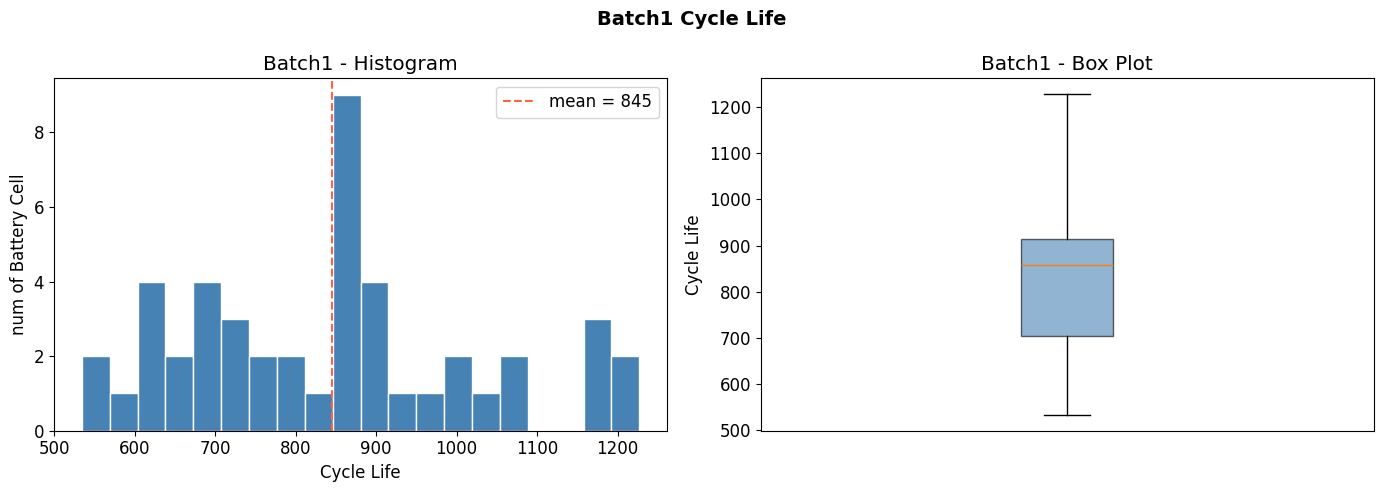


[Batch1] cycle_life describe
count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64
------------------------------------------------------------


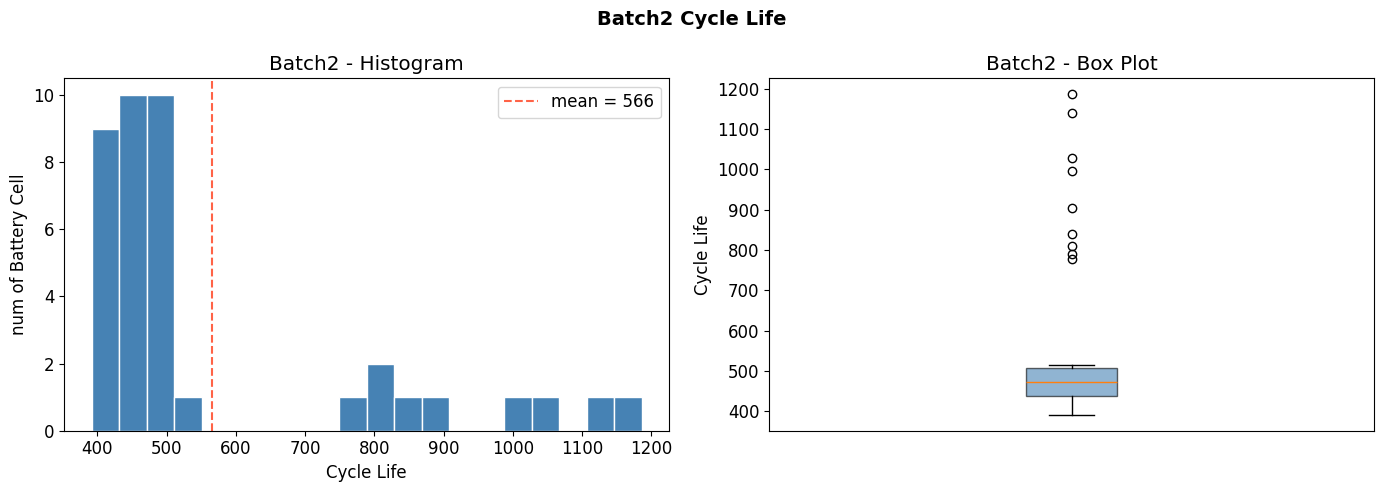


[Batch2] cycle_life describe
count      39.0
mean      565.7
std       222.2
min       392.0
25%       439.5
50%       472.0
75%       508.5
max      1186.0
Name: cycle_life, dtype: float64
------------------------------------------------------------


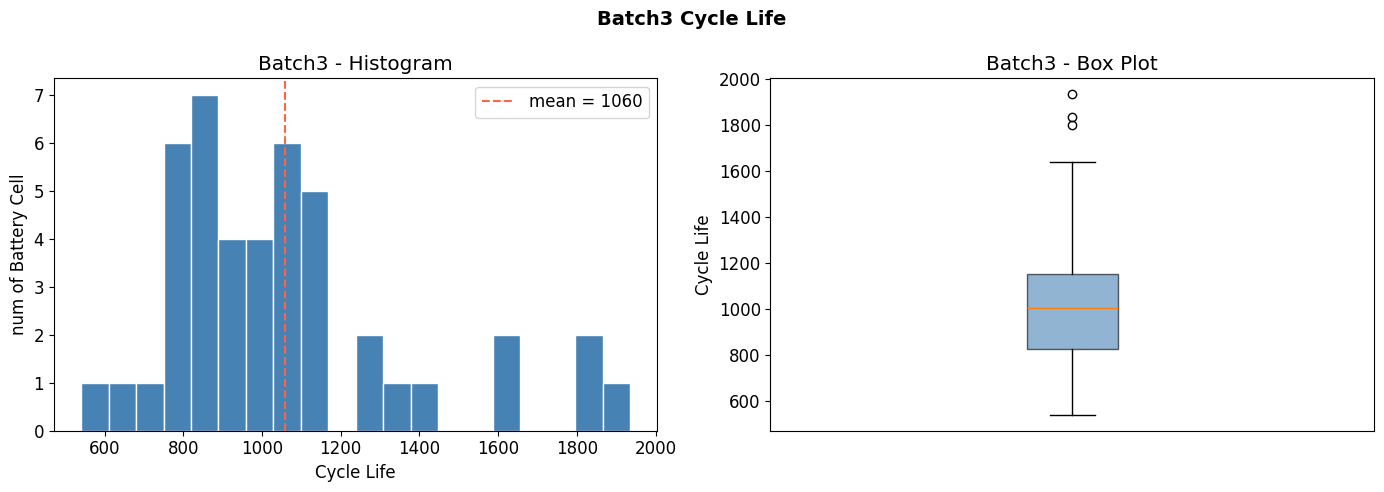


[Batch3] cycle_life describe
count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0
Name: cycle_life, dtype: float64
------------------------------------------------------------


In [27]:
batch_dfs = {
    "Batch1": df_batch1,
    "Batch2": df_batch2,
    "Batch3": df_batch3,
}

plot_cycle_life_by_batch(batch_dfs, bins=20)

In [28]:
def analyze_cycle_life_distribution(batch_dfs):
    """
    배치별 / 전체 cycle_life 분포 분석
    - 장수명 (>1000)
    - 단수명 (<500)
    """

    # 전체 합치기
    total_df = pd.concat(batch_dfs.values(), ignore_index=True)

    print("=" * 60)
    print("전체 데이터")
    print("=" * 60)
    
    cell_df = total_df.groupby(["batch", "cell_id"], as_index=False)["cycle_life"].max()

    long_count = (cell_df["cycle_life"] > 1000).sum()
    short_count = (cell_df["cycle_life"] < 500).sum()
    total = len(cell_df)

    print(f"장수명(>1000): {long_count} / {total} ({long_count/total:.2%})")
    print(f"단수명(<500): {short_count} / {total} ({short_count/total:.2%})")

    print("\n" + "=" * 60)
    print("배치별")
    print("=" * 60)

    # 배치별
    for batch_name, df in batch_dfs.items():
        cell_df = df.groupby("cell_id", as_index=False)["cycle_life"].max()

        long_count = (cell_df["cycle_life"] > 1000).sum()
        short_count = (cell_df["cycle_life"] < 500).sum()
        total = len(cell_df)

        print(f"\n[{batch_name}]")
        print(f"장수명(>1000): {long_count} / {total} ({long_count/total:.2%})")
        print(f"단수명(<500): {short_count} / {total} ({short_count/total:.2%})")

In [29]:
batch_dfs = {
    "Batch1": df_batch1,
    "Batch2": df_batch2,
    "Batch3": df_batch3,
}

analyze_cycle_life_distribution(batch_dfs)

전체 데이터
장수명(>1000): 36 / 129 (27.91%)
단수명(<500): 28 / 129 (21.71%)

배치별

[Batch1]
장수명(>1000): 10 / 46 (21.74%)
단수명(<500): 0 / 46 (0.00%)

[Batch2]
장수명(>1000): 3 / 39 (7.69%)
단수명(<500): 28 / 39 (71.79%)

[Batch3]
장수명(>1000): 23 / 44 (52.27%)
단수명(<500): 0 / 44 (0.00%)


### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

import pandas as pd
import numpy as np

def extract_cycle_level_df(batch, batch_name="batch"):
    records = []

    for i, cell in enumerate(batch):
        summary = cell["summary"]

        qd   = np.array(summary["QDischarge"], dtype=float)
        qc   = np.array(summary["QCharge"], dtype=float)
        ir   = np.array(summary["IR"], dtype=float)
        tmax = np.array(summary["Tmax"], dtype=float)
        tavg = np.array(summary["Tavg"], dtype=float)
        tmin = np.array(summary["Tmin"], dtype=float)
        ct   = np.array(summary["chargetime"], dtype=float)

        cl_raw = cell.get("cycle_life")
        if isinstance(cl_raw, np.ndarray):
            cl_raw = cl_raw.item()

        if cl_raw is None or (isinstance(cl_raw, float) and np.isnan(cl_raw)):
            cycle_life = np.nan
        else:
            cycle_life = cl_raw

        policy = str(cell.get("policy_readable") or cell.get("policy") or "unknown")

        n = len(qd)
        for c in range(n):
            records.append({
                "batch": batch_name,
                "cell_id": i,
                "cycle": c + 1,
                "cycle_life": cycle_life,
                "charging_policy": policy,
                "QD": qd[c],
                "QC": qc[c],
                "IR": ir[c],
                "Tmax": tmax[c],
                "Tavg": tavg[c],
                "Tmin": tmin[c],
                "chargetime": ct[c],
            })

    df = pd.DataFrame(records)

    numeric_cols = ["cycle", "cycle_life", "QD", "QC", "IR", "Tmax", "Tavg", "Tmin", "chargetime"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

def plot_qd_curves_by_batch(batch_dfs):
    """
    배치별 QD-cycle curve 시각화
    batch_dfs: {"Batch1": df_batch1, "Batch2": df_batch2, ...}
    각 df는 cycle, cell_id, QD 컬럼을 포함해야 함
    """
    for batch_name, df in batch_dfs.items():
        fig, ax = plt.subplots(figsize=(14, 6))

        cell_ids = df["cell_id"].unique()
        colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

        for i, cid in enumerate(cell_ids):
            sub = df[df["cell_id"] == cid]
            ax.plot(
                sub["cycle"],
                sub["QD"],
                color=colors[i],
                linewidth=0.8,
                alpha=0.7
            )

        nominal = df[df["cycle"] <= 5].groupby("cell_id")["QD"].mean().mean()

        ax.axhline(
            y=0.88 * nominal,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"EOL(80%) ≈ {0.88 * nominal:.3f} Ah"
        )
        ax.set_xlabel("Cycle")
        ax.set_ylabel("QD (Ah)")
        ax.set_title(f"{batch_name} - Battery Cell QD Curve")
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"[{batch_name}] nominal QD: {nominal:.3f} Ah")
        print(f"[{batch_name}] EOL threshold: {0.88 * nominal:.3f} Ah")
        print("-" * 60)

In [31]:

df_cycle_batch1 = extract_cycle_level_df(batch1_cells, "Batch1")
df_cycle_batch2 = extract_cycle_level_df(batch2_cells, "Batch2")
df_cycle_batch3 = extract_cycle_level_df(batch3_cells, "Batch3")

# summary 결측치 제거 단계에서 살아남은 cell만 남겨
# 이후 cycle-level / outlier filtering / 상관분석도 동일 기준으로 맞춥니다.
df_cycle_batch1 = df_cycle_batch1[df_cycle_batch1["cell_id"].isin(valid_cell_ids_by_batch["Batch1"])].copy()
df_cycle_batch2 = df_cycle_batch2[df_cycle_batch2["cell_id"].isin(valid_cell_ids_by_batch["Batch2"])].copy()
df_cycle_batch3 = df_cycle_batch3[df_cycle_batch3["cell_id"].isin(valid_cell_ids_by_batch["Batch3"])].copy()

print("Cycle-level rows after summary-missing filtering:")
print("Batch1:", df_cycle_batch1.shape)
print("Batch2:", df_cycle_batch2.shape)
print("Batch3:", df_cycle_batch3.shape)


Cycle-level rows after summary-missing filtering:
Batch1: (38811, 12)
Batch2: (23034, 12)
Batch3: (46581, 12)


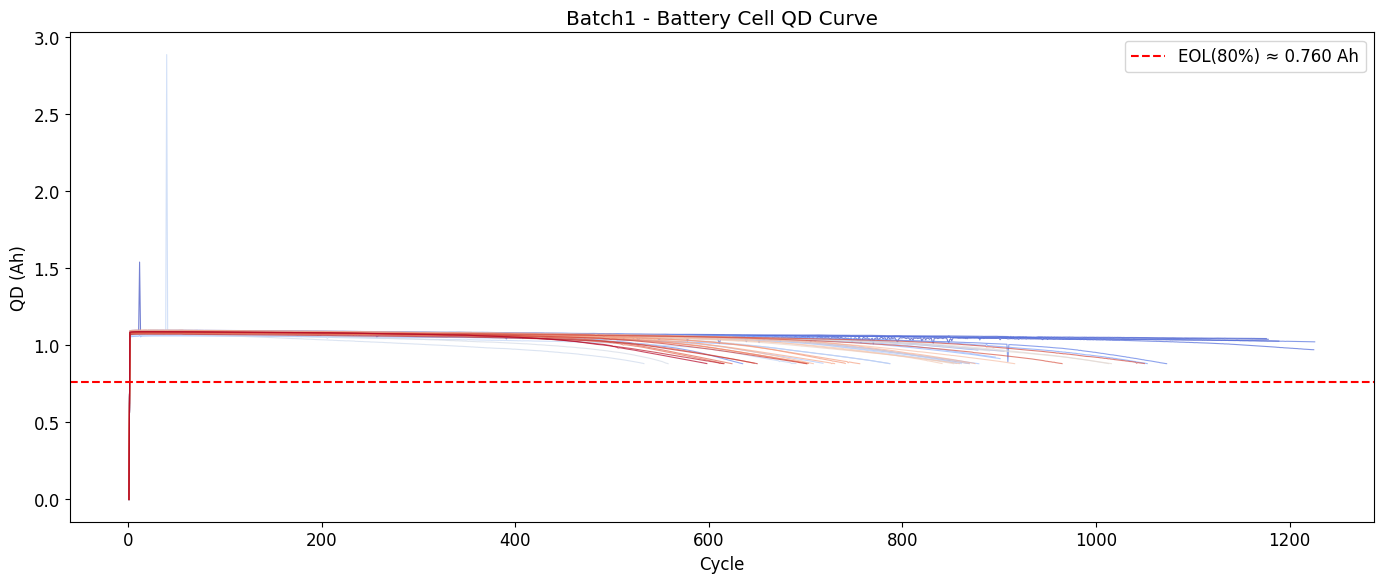

[Batch1] nominal QD: 0.864 Ah
[Batch1] EOL threshold: 0.760 Ah
------------------------------------------------------------


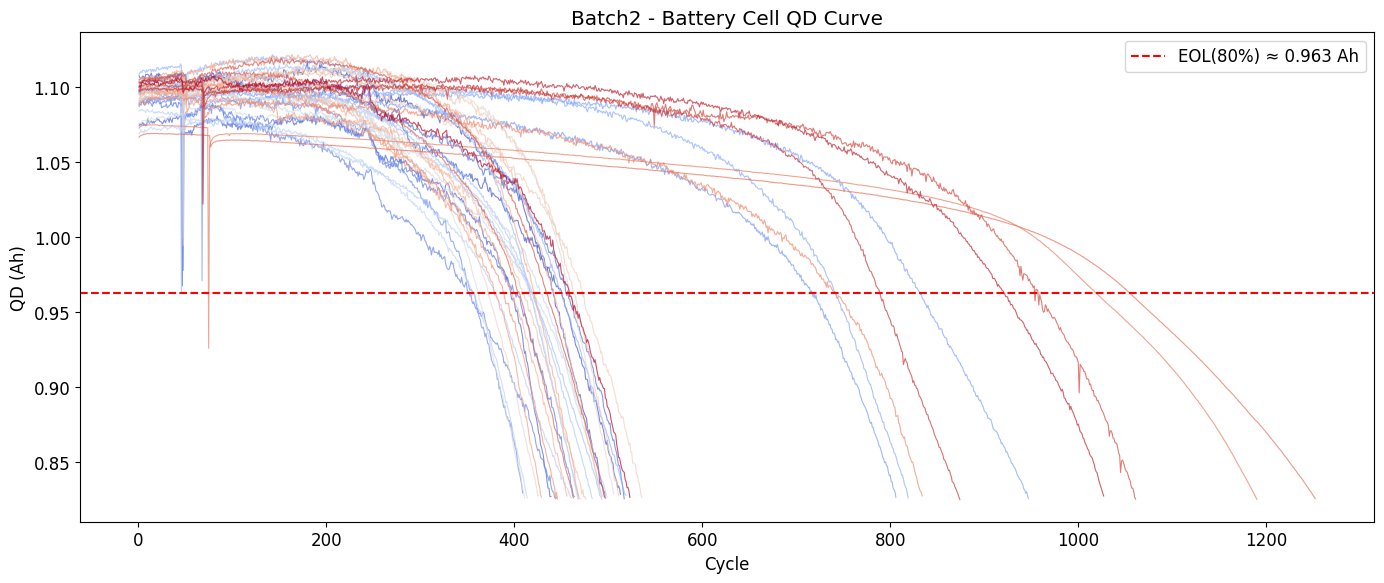

[Batch2] nominal QD: 1.094 Ah
[Batch2] EOL threshold: 0.963 Ah
------------------------------------------------------------


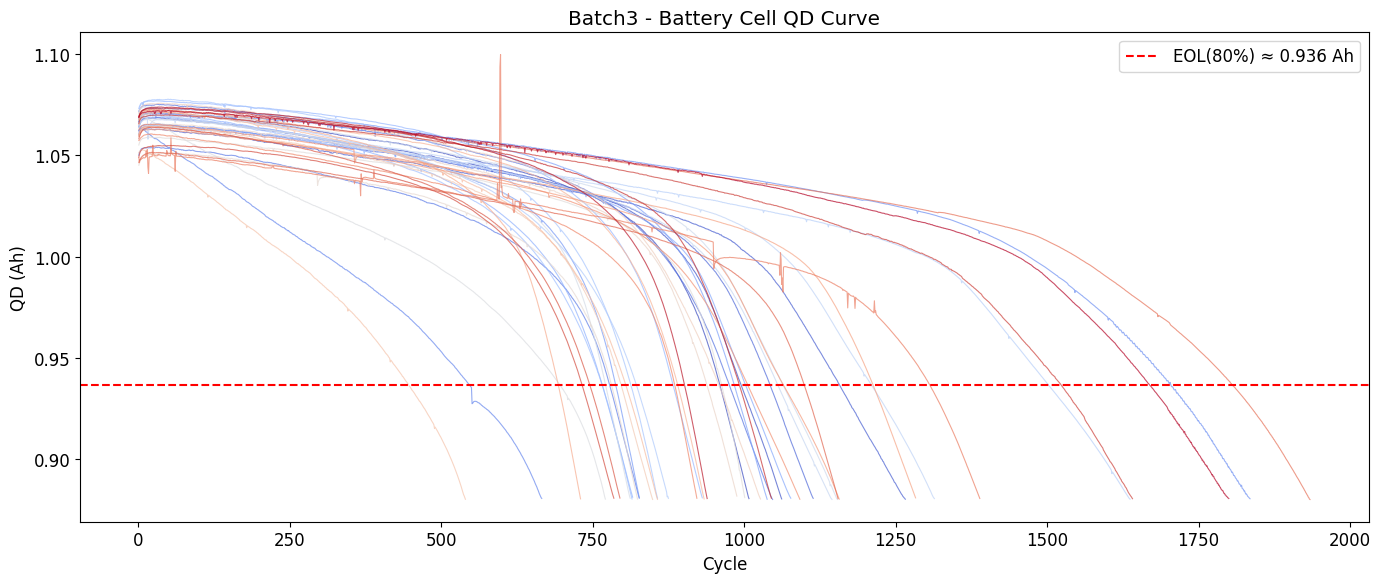

[Batch3] nominal QD: 1.064 Ah
[Batch3] EOL threshold: 0.936 Ah
------------------------------------------------------------


In [32]:
batch_cycle_dfs = {
    "Batch1": df_cycle_batch1,
    "Batch2": df_cycle_batch2,
    "Batch3": df_cycle_batch3,
}

plot_qd_curves_by_batch(batch_cycle_dfs)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_qd_curve_with_outlier_filter(batch_name, df, y_min=0.7, y_max=1.2):
    """
    배치별 QD outlier 필터링 후 열화 곡선 시각화
    df: cycle 기준 DataFrame
    """

    # 1. 정상 용량 범위 정의
    nominal = df[df["cycle"] <= 5].groupby("cell_id")["QD"].median().median()
    lower = nominal * 0.80
    upper = nominal * 1.20

    print(f"\n[{batch_name}]")
    print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
    print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

    # 2. 필터링
    df_clean = df[df["QD"].between(lower, upper)].copy()
    removed_n = len(df) - len(df_clean)
    removed_pct = removed_n / len(df) * 100

    print(f"제거된 행 수       : {removed_n} ({removed_pct:.2f}%)")

    # 3. 시각화
    fig, ax = plt.subplots(figsize=(14, 6))

    cell_ids = df_clean["cell_id"].unique()
    colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

    for i, cid in enumerate(cell_ids):
        sub = df_clean[df_clean["cell_id"] == cid]
        ax.plot(
            sub["cycle"],
            sub["QD"],
            color=colors[i],
            linewidth=0.8,
            alpha=0.7
        )

    ax.axhline(
        y=nominal * 0.8,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"EOL ({nominal * 0.8:.2f} Ah)"
    )
    ax.set_xlabel("Cycle")
    ax.set_ylabel("QD (Ah)")
    ax.set_title(f"{batch_name} - Battery Cell QD Curve (Outlier Filtering)")
    ax.set_ylim(y_min, y_max)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df_clean


[Batch1]
공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


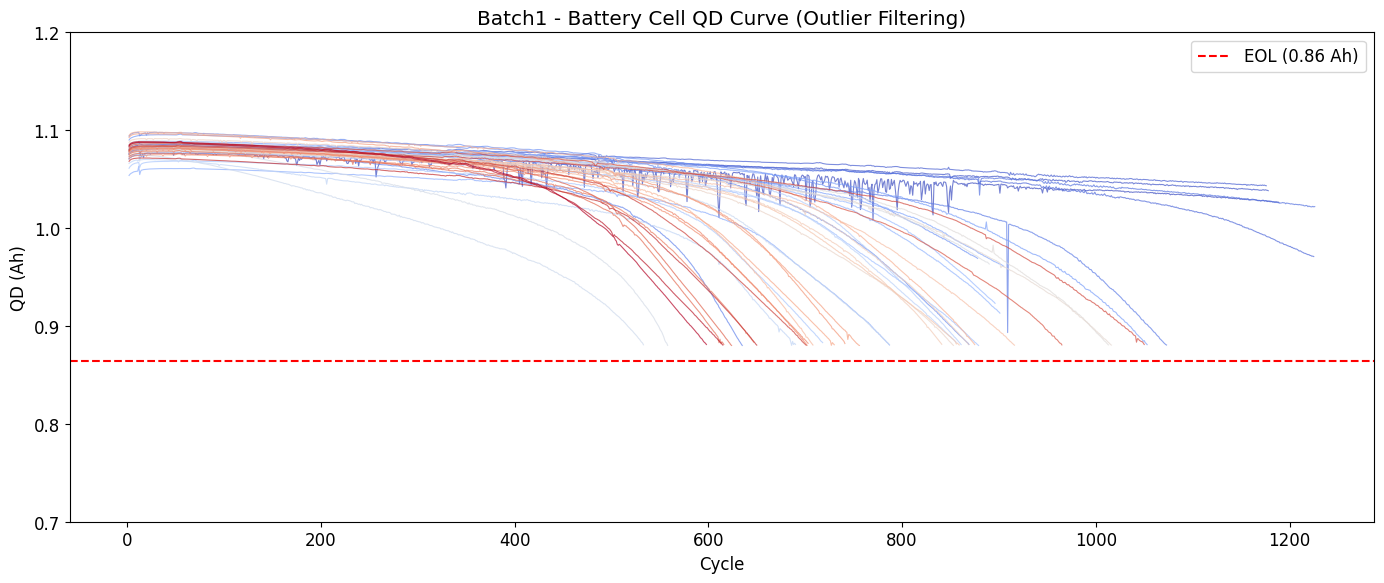


[Batch2]
공칭 용량(nominal) : 1.0962 Ah
필터 범위          : 0.8769 ~ 1.3154 Ah
제거된 행 수       : 944 (4.10%)


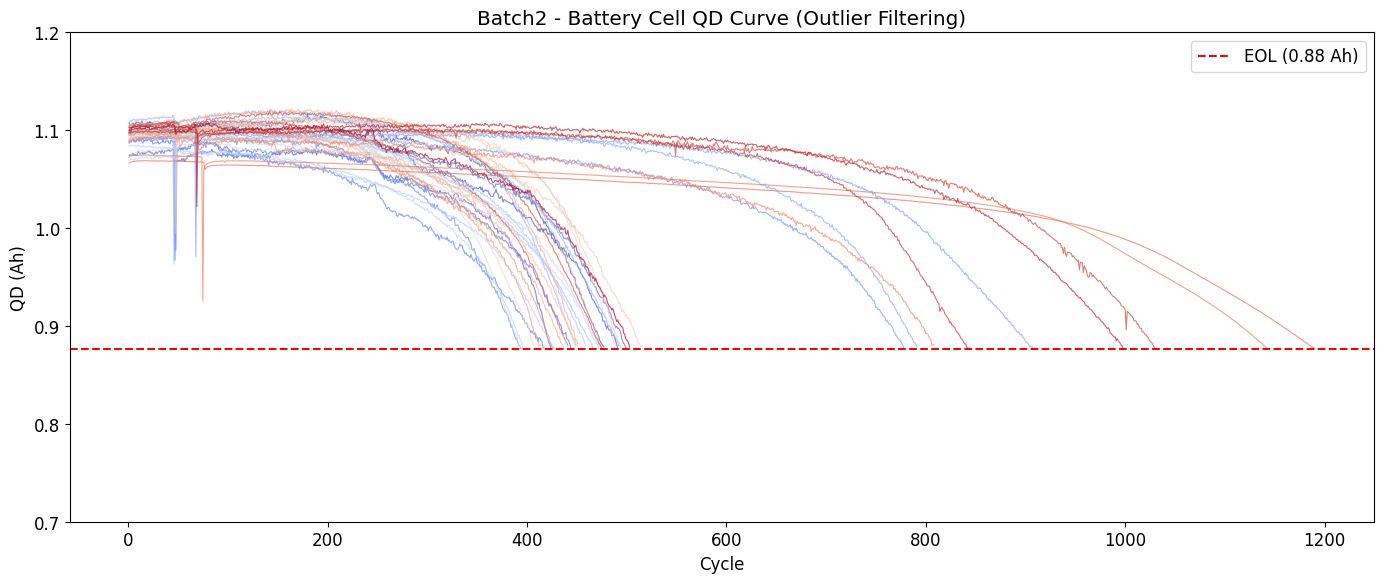


[Batch3]
공칭 용량(nominal) : 1.0664 Ah
필터 범위          : 0.8531 ~ 1.2796 Ah
제거된 행 수       : 0 (0.00%)


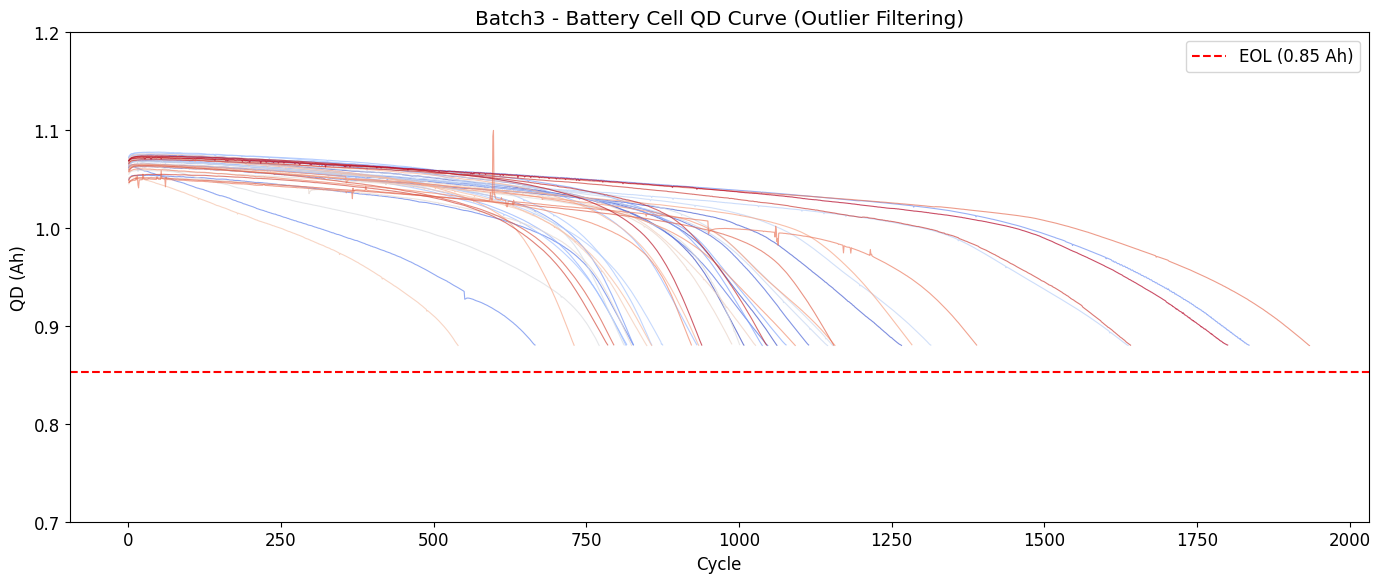

In [34]:
df_clean_batch1 = plot_qd_curve_with_outlier_filter("Batch1", df_cycle_batch1)
df_clean_batch2 = plot_qd_curve_with_outlier_filter("Batch2", df_cycle_batch2)
df_clean_batch3 = plot_qd_curve_with_outlier_filter("Batch3", df_cycle_batch3)

### 3. ΔQ(V) 곡선 분석

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_cycles_list(cell):
    cycles_list = cell["cycles"]
    if isinstance(cycles_list, dict):
        keys = list(cycles_list.keys())
        n = len(cycles_list[keys[0]])
        cycles_list = [{k: cycles_list[k][i] for k in keys} for i in range(n)]
    return cycles_list


def get_delta_qv(cell, cycle_a=10, cycle_b=100):
    cycles_list = get_cycles_list(cell)

    if len(cycles_list) < cycle_b:
        return None, None

    ca = cycles_list[cycle_a - 1]
    cb = cycles_list[cycle_b - 1]

    q_a = np.array(ca["Qdlin"]).flatten()
    q_b = np.array(cb["Qdlin"]).flatten()
    v = np.array(cell["Vdlin"]).flatten()

    min_len = min(len(v), len(q_a), len(q_b))
    if min_len == 0:
        return None, None

    v = v[:min_len]
    delta = q_b[:min_len] - q_a[:min_len]
    return v, delta


def analyze_delta_qv(df_clean, batch, batch_name="Batch", cycle_a=10, cycle_b=100, sample_n=3):
    # 1. cell_id별 대표 cycle_life
    cycle_life_df = df_clean.groupby("cell_id", as_index=False)["cycle_life"].max()
    cycle_life_df = cycle_life_df.dropna(subset=["cycle_life"]).copy()

    # 2. 분위수 기준 그룹 분리
    q25 = cycle_life_df["cycle_life"].quantile(0.25)
    q75 = cycle_life_df["cycle_life"].quantile(0.75)

    long_cells = cycle_life_df[cycle_life_df["cycle_life"] >= q75]["cell_id"].tolist()
    short_cells = cycle_life_df[cycle_life_df["cycle_life"] <= q25]["cell_id"].tolist()

    print(f"\n[{batch_name}]")
    print(f"Q1(하위 25%) 기준 : {q25:.2f}")
    print(f"Q3(상위 25%) 기준 : {q75:.2f}")
    print(f"Long cells 수     : {len(long_cells)}")
    print(f"Short cells 수    : {len(short_cells)}")

    # 3. 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 3-1. 샘플 셀 ΔQ(V)
    for cid in long_cells[:sample_n]:
        v, delta = get_delta_qv(batch[cid], cycle_a, cycle_b)
        if v is not None:
            axes[0].plot(v, delta, label=f"Long Cell {cid}", linewidth=1.5)

    for cid in short_cells[:sample_n]:
        v, delta = get_delta_qv(batch[cid], cycle_a, cycle_b)
        if v is not None:
            axes[0].plot(v, delta, "--", label=f"Short Cell {cid}", linewidth=1.5)

    axes[0].set_xlabel("Voltage (V)")
    axes[0].set_ylabel("ΔQ(V)")
    axes[0].set_title(f"{batch_name} Sample ΔQ(V): Cycle {cycle_b} - Cycle {cycle_a}")
    axes[0].legend(fontsize=8)

    # 3-2. 그룹 평균 ΔQ(V)
    long_curves = []
    short_curves = []
    v_ref = None

    for cid in long_cells:
        v, delta = get_delta_qv(batch[cid], cycle_a, cycle_b)
        if v is not None:
            long_curves.append(delta)
            if v_ref is None:
                v_ref = v

    for cid in short_cells:
        v, delta = get_delta_qv(batch[cid], cycle_a, cycle_b)
        if v is not None:
            short_curves.append(delta)
            if v_ref is None:
                v_ref = v

    if len(long_curves) > 0:
        long_arr = np.vstack(long_curves)
        axes[1].plot(v_ref, long_arr.mean(axis=0), label="Long-life mean", linewidth=2)

    if len(short_curves) > 0:
        short_arr = np.vstack(short_curves)
        axes[1].plot(v_ref, short_arr.mean(axis=0), label="Short-life mean", linewidth=2)

    axes[1].set_xlabel("Voltage (V)")
    axes[1].set_ylabel("ΔQ(V)")
    axes[1].set_title(f"{batch_name} Mean ΔQ(V) by Life Group")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # 4. 통계 피처 후보 추출
    features = []

    for cid in cycle_life_df["cell_id"]:
        v, delta = get_delta_qv(batch[cid], cycle_a, cycle_b)
        if v is None:
            continue

        delta_area = float(np.trapezoid(delta, v)) if hasattr(np, "trapezoid") else float(np.trapz(delta, v))

        features.append({
            "cell_id": cid,
            "delta_mean": float(np.mean(delta)),
            "delta_std": float(np.std(delta)),
            "delta_min": float(np.min(delta)),
            "delta_max": float(np.max(delta)),
            "delta_range": float(np.max(delta) - np.min(delta)),
            "delta_area": delta_area,
        })

    delta_feature_df = pd.DataFrame(features).merge(cycle_life_df, on="cell_id", how="left")

    print(f"\n[{batch_name}] delta_feature_df")
    display(delta_feature_df.head())

    corr_df = delta_feature_df.corr(numeric_only=True)[["cycle_life"]].sort_values("cycle_life", ascending=False)

    print(f"\n[{batch_name}] correlation with cycle_life")
    display(corr_df)

    return delta_feature_df, corr_df


[Batch1]
Q1(하위 25%) 기준 : 703.25
Q3(상위 25%) 기준 : 914.25
Long cells 수     : 12
Short cells 수    : 12


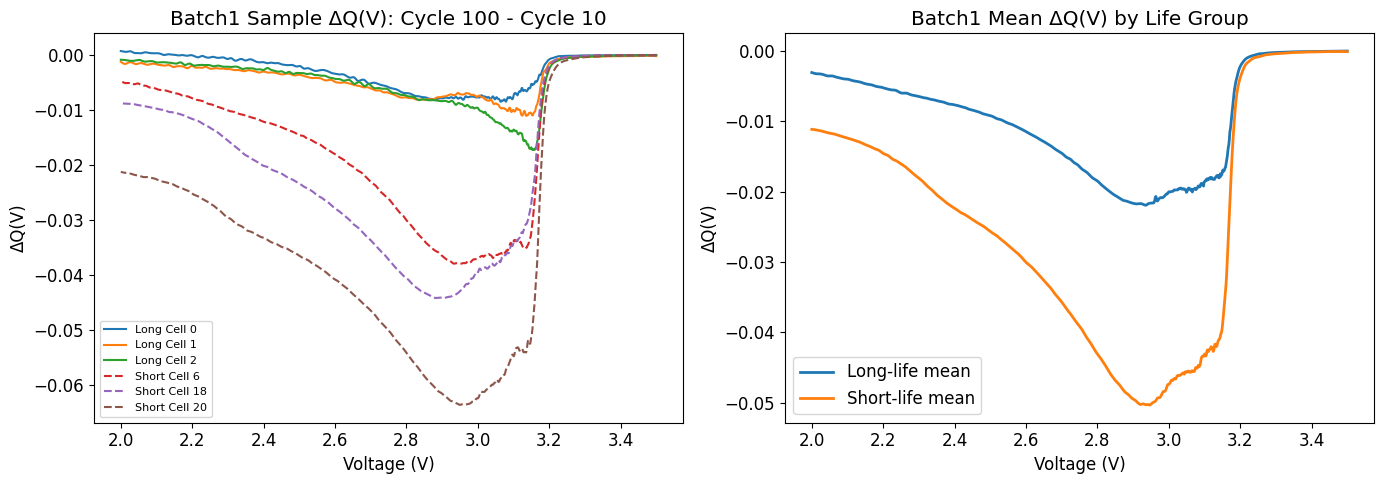


[Batch1] delta_feature_df


,cell_id,delta_mean,delta_std,delta_min,delta_max,delta_range,delta_area,cycle_life
0,0,-0.002873,0.003109,-0.008460,0.000768,0.009228,0.004315,1190.0
1,1,-0.004100,0.003112,-0.011004,-0.000088,0.010916,0.006155,1179.0
2,2,-0.004487,0.004281,-0.017216,0.000013,0.017229,0.006736,1177.0
3,3,-0.007456,0.006007,-0.018961,0.000182,0.019143,0.011194,1226.0
4,4,-0.005750,0.004744,-0.013958,0.000046,0.014004,0.008633,1227.0



[Batch1] correlation with cycle_life


,cycle_life
cycle_life,1.000000
delta_min,0.881645
delta_mean,0.853810
delta_max,0.263917
cell_id,-0.601802
delta_area,-0.853841
delta_range,-0.881866
delta_std,-0.893713



[Batch2]
Q1(하위 25%) 기준 : 439.50
Q3(상위 25%) 기준 : 508.50
Long cells 수     : 10
Short cells 수    : 10


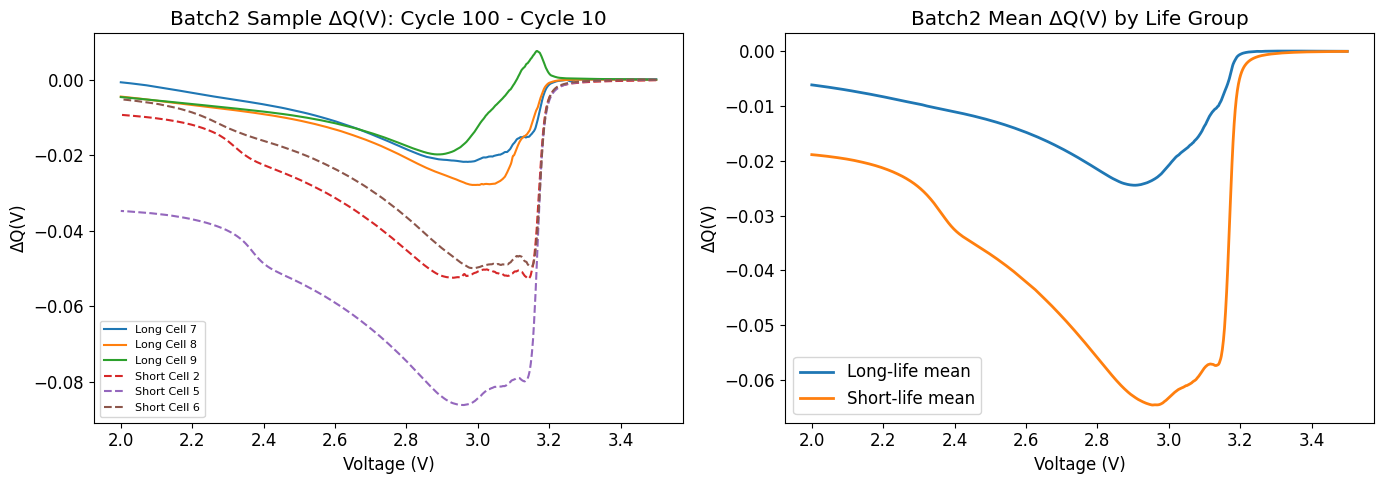


[Batch2] delta_feature_df


,cell_id,delta_mean,delta_std,delta_min,delta_max,delta_range,delta_area,cycle_life
0,0,-0.025801,0.018045,-0.055061,-0.000095,0.054966,0.038731,477.0
1,1,-0.035595,0.022437,-0.066115,0.000071,0.066186,0.053428,491.0
2,2,-0.025013,0.018616,-0.052718,-0.000093,0.052624,0.037551,424.0
3,3,-0.020090,0.017860,-0.055868,-0.000036,0.055832,0.030162,499.0
4,4,-0.034782,0.024196,-0.070297,0.000130,0.070427,0.052211,444.0



[Batch2] correlation with cycle_life


,cycle_life
cycle_life,1.000000
delta_min,0.818518
delta_mean,0.767085
delta_max,0.498110
cell_id,0.378693
delta_area,-0.767165
delta_range,-0.801750
delta_std,-0.834546



[Batch3]
Q1(하위 25%) 기준 : 828.00
Q3(상위 25%) 기준 : 1155.25
Long cells 수     : 11
Short cells 수    : 12


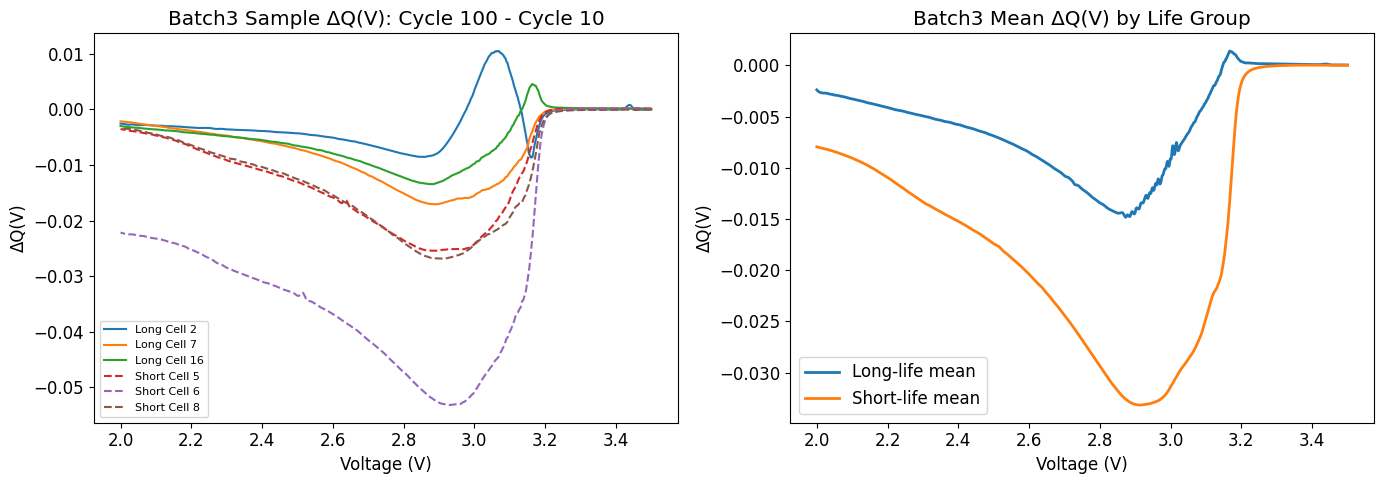


[Batch3] delta_feature_df


,cell_id,delta_mean,delta_std,delta_min,delta_max,delta_range,delta_area,cycle_life
0,0,-0.010102,0.007541,-0.023312,0.000042,0.023354,0.015166,1009.0
1,1,-0.009621,0.007198,-0.022324,-0.000152,0.022172,0.014443,1063.0
2,2,-0.002613,0.004077,-0.008648,0.010524,0.019172,0.003922,1267.0
3,3,-0.010705,0.008744,-0.026837,0.000073,0.026909,0.016071,1115.0
4,4,-0.010106,0.008143,-0.024810,-0.000049,0.024761,0.015172,1048.0



[Batch3] correlation with cycle_life


,cycle_life
cycle_life,1.000000
delta_min,0.692116
delta_mean,0.639115
delta_max,0.407698
cell_id,0.166223
delta_range,-0.601037
delta_area,-0.639173
delta_std,-0.672606


In [36]:
delta_feat_b1, corr_b1 = analyze_delta_qv(
    df_clean=df_clean_batch1,
    batch=batch1_cells,
    batch_name="Batch1",
    cycle_a=10,
    cycle_b=100
)

delta_feat_b2, corr_b2 = analyze_delta_qv(
    df_clean=df_clean_batch2,
    batch=batch2_cells,
    batch_name="Batch2",
    cycle_a=10,
    cycle_b=100
)

delta_feat_b3, corr_b3 = analyze_delta_qv(
    df_clean=df_clean_batch3,
    batch=batch3_cells,
    batch_name="Batch3",
    cycle_a=10,
    cycle_b=100
)

### 4. 충전 정책(C-rate)과 수명의 관계

In [37]:
def plot_cycle_by_policy(df, batch_num):
    data = (
        df[df["batch"] == batch_num]   # batch 필터링
        .groupby("charging_policy")["cycle_life"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12,6))
    data.plot(kind="bar")

    plt.ylabel("Cycle Life")
    plt.xlabel("Charging Policy")
    plt.title(f"Batch {batch_num} - Cycle Life by Charging Policy")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 4. 충전 정책(C-rate)과 수명의 관계 - Revised

아래 셀은 기존 내용을 유지하면서, 중복을 줄이고 변수 혼선을 줄이도록 정리한 최종 버전입니다.

- summary 데이터: `df_batch1`, `df_batch2`, `df_batch3`
- cycle-level 데이터: `df_cycle_batch1`, `df_cycle_batch2`, `df_cycle_batch3`
- clean cycle-level 데이터: `df_clean_batch1`, `df_clean_batch2`, `df_clean_batch3`

In [38]:
# batch별 데이터 관리용 dictionary
summary_batches = {
    "Batch1": df_batch1,
    "Batch2": df_batch2,
    "Batch3": df_batch3,
}

cycle_batches = {
    "Batch1": df_cycle_batch1,
    "Batch2": df_cycle_batch2,
    "Batch3": df_cycle_batch3,
}

clean_cycle_batches = {
    "Batch1": df_clean_batch1,
    "Batch2": df_clean_batch2,
    "Batch3": df_clean_batch3,
}


def extract_crate(series):
    """charging policy 문자열에서 첫 번째 C-rate를 추출"""
    return pd.to_numeric(series.astype(str).str.extract(r"(\d+\.?\d*)C", expand=False), errors="coerce")

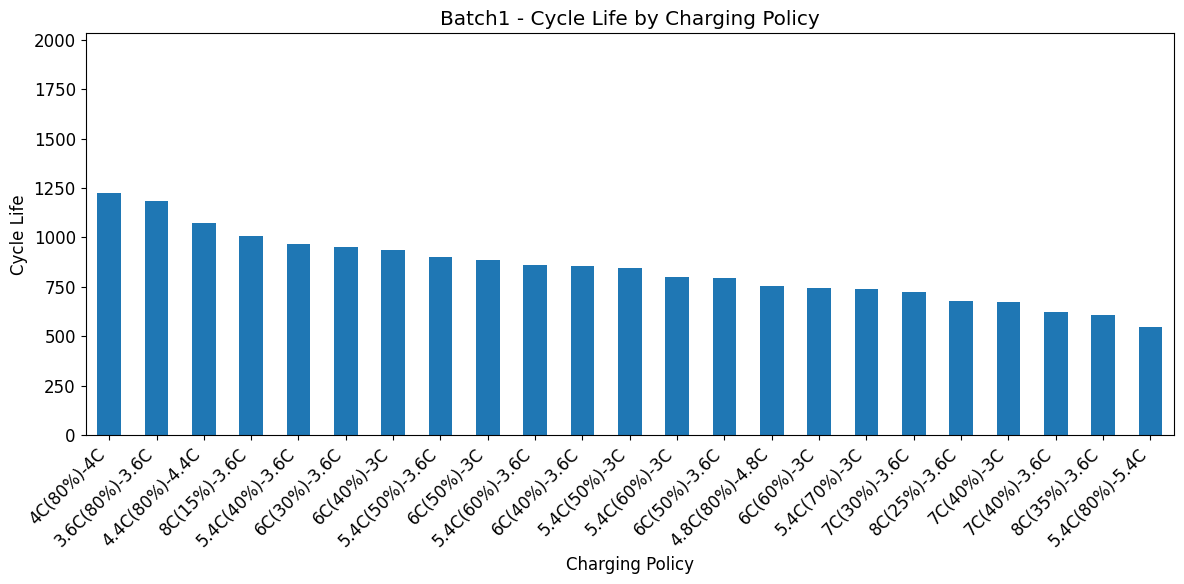

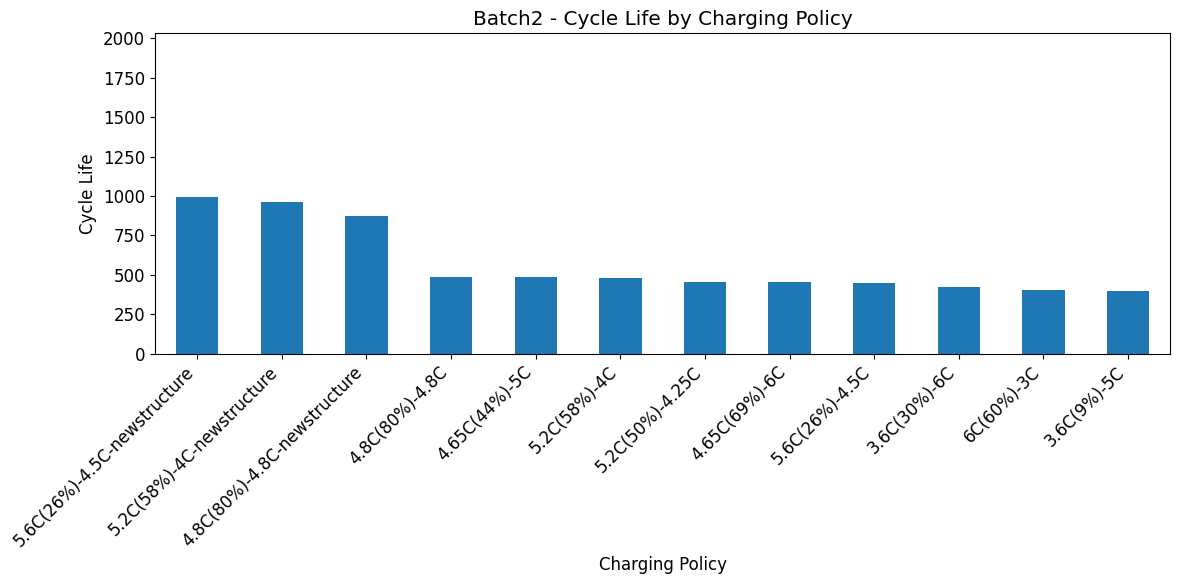

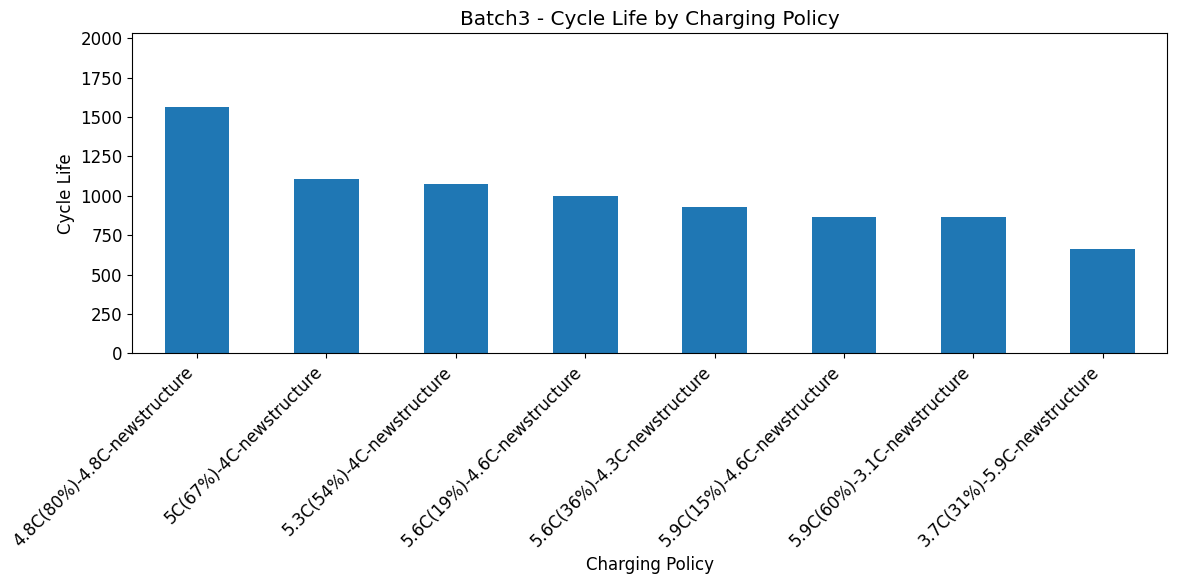

In [39]:
def plot_cycle_by_policy(summary_df, batch_name, use_clean_label=False, ylim=None):
    """정책별 평균 cycle life를 bar chart로 시각화"""
    policy_col = "charging_policy_clean" if use_clean_label and "charging_policy_clean" in summary_df.columns else "charging_policy"

    plot_df = (
        summary_df.dropna(subset=["cycle_life", policy_col])
        .groupby(policy_col)["cycle_life"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    plot_df.plot(kind="bar")

    plt.ylabel("Cycle Life")
    plt.xlabel("Charging Policy")
    plt.title(f"{batch_name} - Cycle Life by Charging Policy")

    if ylim is not None:
        plt.ylim(ylim)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return plot_df


common_ylim = (
    0,
    max(
        df_batch1["cycle_life"].max(),
        df_batch2["cycle_life"].max(),
        df_batch3["cycle_life"].max(),
    ) * 1.05,
)

policy_life_tables = {}
for batch_name, summary_df in summary_batches.items():
    policy_life_tables[batch_name] = plot_cycle_by_policy(summary_df, batch_name, ylim=common_ylim)

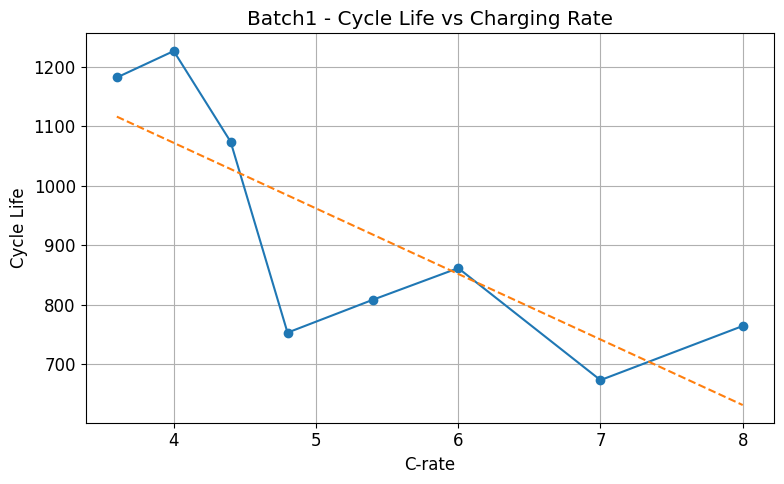

Batch1 Pearson correlation (C-rate vs cycle_life): -0.791


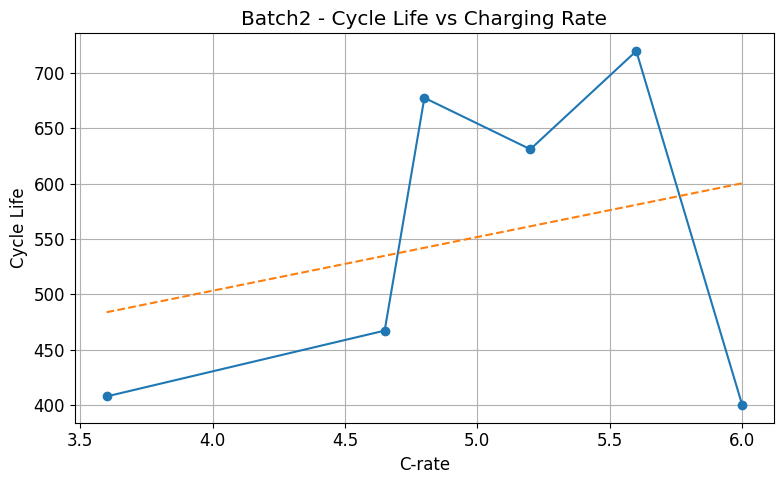

Batch2 Pearson correlation (C-rate vs cycle_life): 0.286


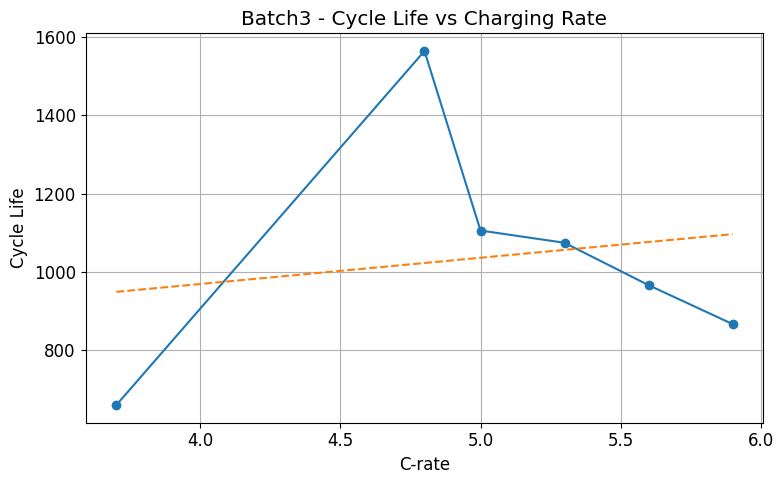

Batch3 Pearson correlation (C-rate vs cycle_life): 0.170


In [40]:
def plot_cycle_vs_crate_trend(summary_df, batch_name, degree=1):
    """정책별 평균 cycle life를 C-rate 기준으로 묶고 추세선을 시각화"""
    plot_df = (
        summary_df.groupby("charging_policy", as_index=False)["cycle_life"]
        .mean()
        .rename(columns={"charging_policy": "policy"})
    )

    plot_df["C_rate"] = extract_crate(plot_df["policy"])
    plot_df = plot_df.dropna(subset=["C_rate", "cycle_life"])

    grouped = (
        plot_df.groupby("C_rate", as_index=False)["cycle_life"]
        .mean()
        .sort_values("C_rate")
    )

    x = grouped["C_rate"].to_numpy()
    y = grouped["cycle_life"].to_numpy()

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker="o")

    if len(x) >= degree + 1:
        coef = np.polyfit(x, y, deg=degree)
        trend = np.poly1d(coef)
        x_line = np.linspace(x.min(), x.max(), 100)
        plt.plot(x_line, trend(x_line), linestyle="--")

    plt.xlabel("C-rate")
    plt.ylabel("Cycle Life")
    plt.title(f"{batch_name} - Cycle Life vs Charging Rate")
    plt.grid()
    plt.tight_layout()
    plt.show()

    corr = grouped["C_rate"].corr(grouped["cycle_life"])
    print(f"{batch_name} Pearson correlation (C-rate vs cycle_life): {corr:.3f}")

    return grouped, corr


crate_life_results = {}
for batch_name, summary_df in summary_batches.items():
    crate_life_results[batch_name] = plot_cycle_vs_crate_trend(summary_df, batch_name, degree=1)

Batch1 Pearson correlation (C-rate vs deg_rate): -0.640


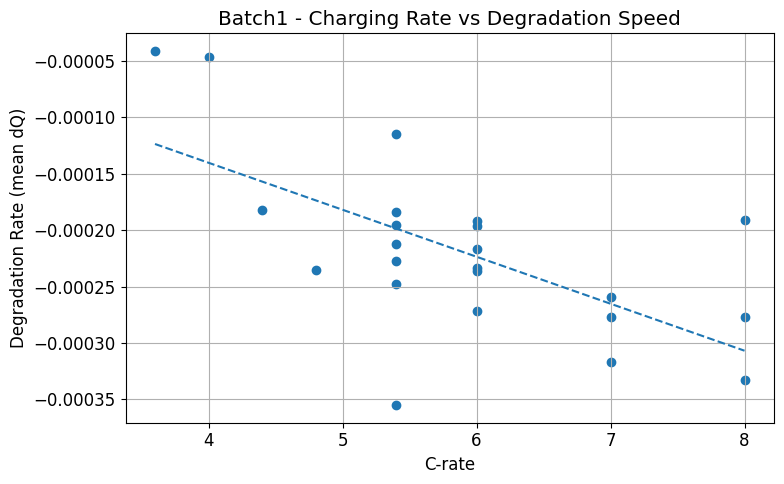

Batch2 Pearson correlation (C-rate vs deg_rate): 0.273


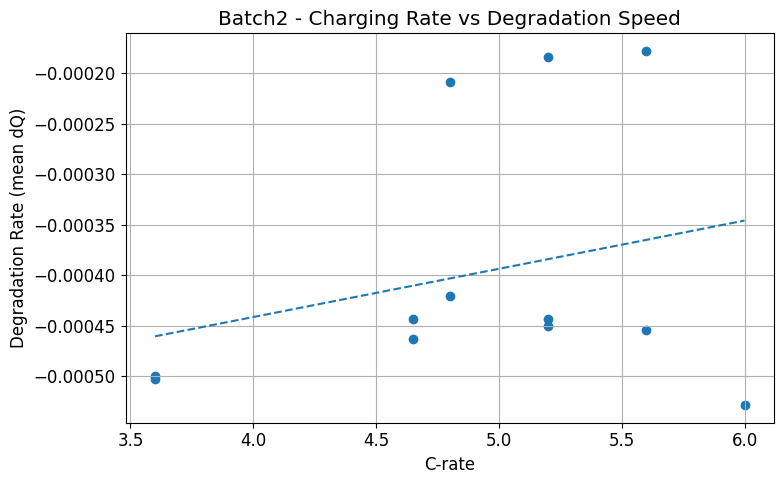

Batch3 Pearson correlation (C-rate vs deg_rate): 0.120


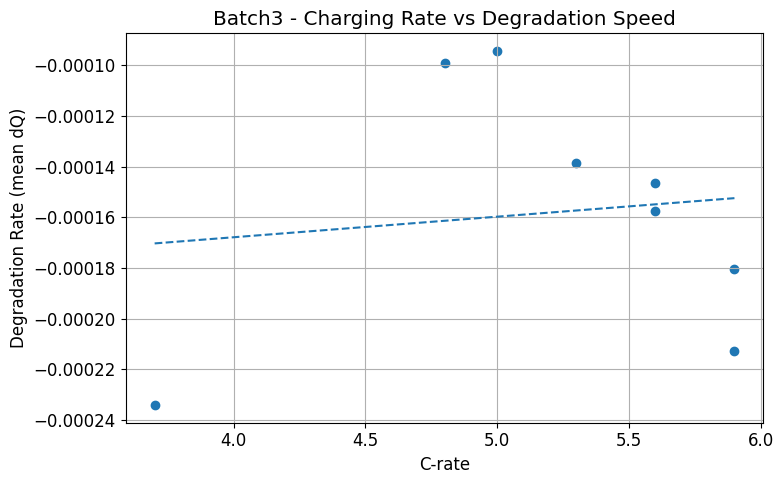

In [41]:
def plot_crate_vs_deg_rate(cycle_df, batch_name):
    """정책별 평균 QD 곡선에서 열화 속도를 계산하고 C-rate와의 관계를 시각화"""
    avg_qd = (
        cycle_df.groupby(["charging_policy", "cycle"], as_index=False)["QD"]
        .mean()
        .sort_values(["charging_policy", "cycle"])
    )

    avg_qd["dQ"] = avg_qd.groupby("charging_policy")["QD"].diff()

    policy_df = (
        avg_qd.groupby("charging_policy", as_index=False)["dQ"]
        .mean()
        .rename(columns={"charging_policy": "policy", "dQ": "deg_rate"})
    )

    policy_df["C_rate"] = extract_crate(policy_df["policy"])
    policy_df = policy_df.dropna(subset=["C_rate", "deg_rate"]).sort_values("C_rate")

    corr = policy_df["C_rate"].corr(policy_df["deg_rate"])
    print(f"{batch_name} Pearson correlation (C-rate vs deg_rate): {corr:.3f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(policy_df["C_rate"], policy_df["deg_rate"])

    if len(policy_df) >= 2:
        coef = np.polyfit(policy_df["C_rate"], policy_df["deg_rate"], deg=1)
        trend = np.poly1d(coef)
        x_line = np.linspace(policy_df["C_rate"].min(), policy_df["C_rate"].max(), 100)
        plt.plot(x_line, trend(x_line), linestyle="--")

    plt.xlabel("C-rate")
    plt.ylabel("Degradation Rate (mean dQ)")
    plt.title(f"{batch_name} - Charging Rate vs Degradation Speed")
    plt.grid()
    plt.tight_layout()
    plt.show()

    return policy_df, corr


deg_rate_results = {}
for batch_name, cycle_df in clean_cycle_batches.items():
    deg_rate_results[batch_name] = plot_crate_vs_deg_rate(cycle_df, batch_name)

In [42]:
def summarize_cycle_crate_corr(summary_df, batch_name):
    """정책별 평균 cycle life와 C-rate 상관계수만 간단히 확인"""
    policy_df = (
        summary_df.groupby("charging_policy", as_index=False)["cycle_life"]
        .mean()
        .rename(columns={"charging_policy": "policy"})
    )

    policy_df["C_rate"] = extract_crate(policy_df["policy"])
    policy_df = policy_df.dropna(subset=["C_rate", "cycle_life"]).sort_values("C_rate")

    corr = policy_df["C_rate"].corr(policy_df["cycle_life"])
    print(f"{batch_name} Pearson correlation (policy mean): {corr:.3f}")

    return policy_df, corr


cycle_crate_corr_results = {}
for batch_name, summary_df in summary_batches.items():
    cycle_crate_corr_results[batch_name] = summarize_cycle_crate_corr(summary_df, batch_name)

Batch1 Pearson correlation (policy mean): -0.583
Batch2 Pearson correlation (policy mean): 0.287
Batch3 Pearson correlation (policy mean): 0.041


## 5. 상관관계 히트맵 - Revised

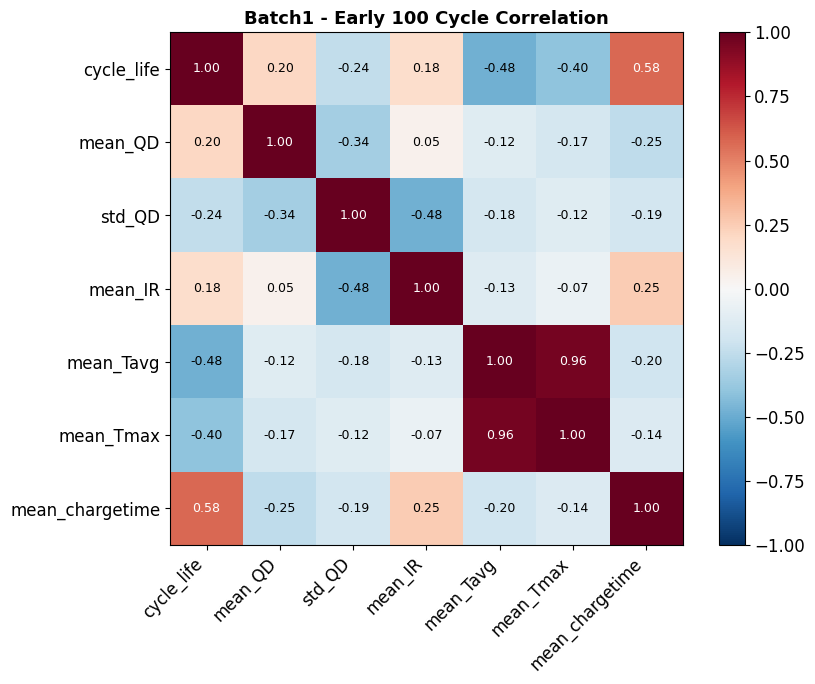


[Batch1 - cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
std_QD            -0.243
mean_QD            0.205
mean_IR            0.176
Name: cycle_life, dtype: float64


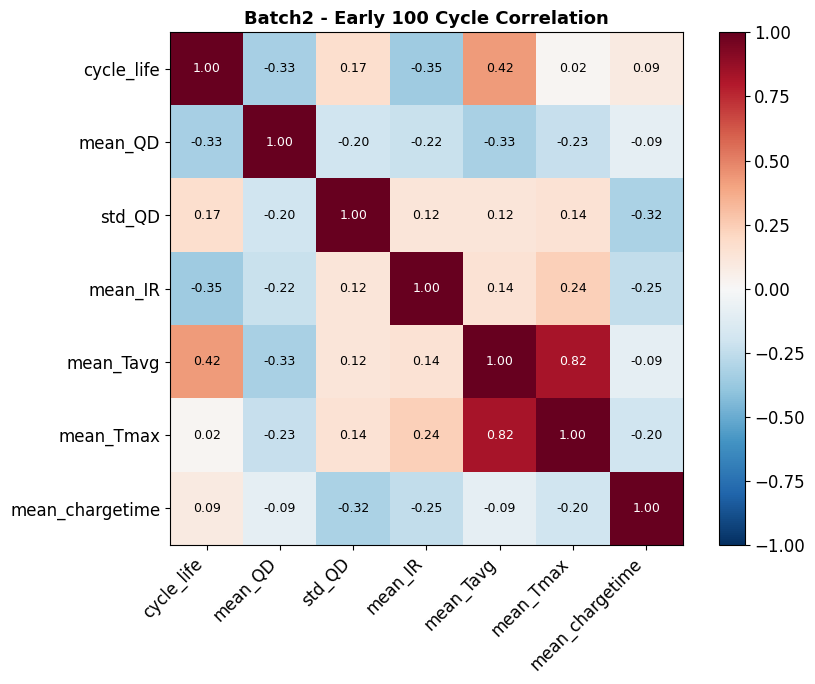


[Batch2 - cycle_life Corr Rank]
mean_Tavg          0.425
mean_IR           -0.353
mean_QD           -0.332
std_QD             0.171
mean_chargetime    0.087
mean_Tmax          0.019
Name: cycle_life, dtype: float64


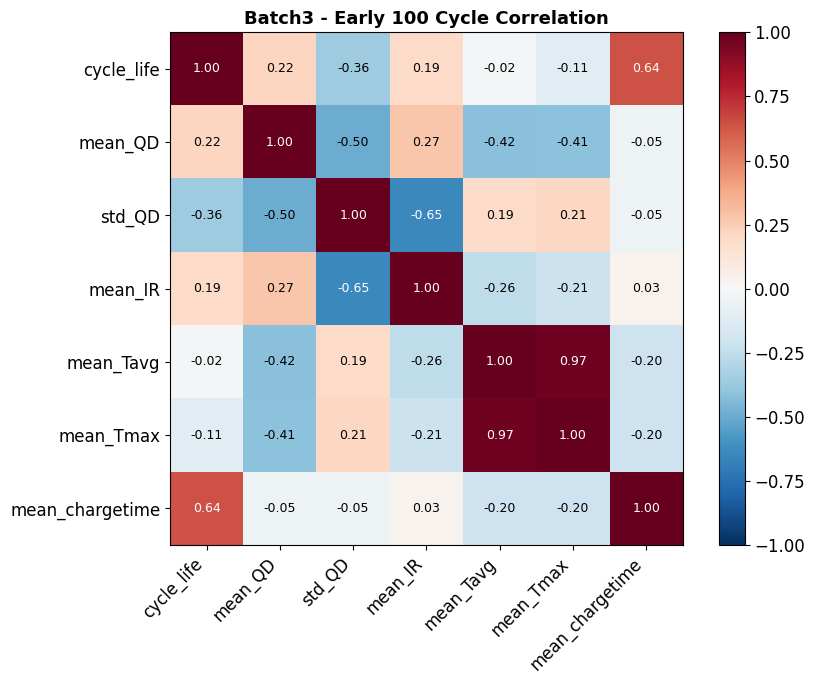


[Batch3 - cycle_life Corr Rank]
mean_chargetime    0.637
std_QD            -0.356
mean_QD            0.217
mean_IR            0.190
mean_Tmax         -0.106
mean_Tavg         -0.022
Name: cycle_life, dtype: float64


In [43]:
def plot_early_corr(cycle_df, batch_name, cycle_threshold=100):
    """초기 구간 평균 feature 기준 상관관계 히트맵과 cycle_life 상관 순위 출력"""
    early = (
        cycle_df[cycle_df["cycle"] <= cycle_threshold]
        .groupby("cell_id")
        .agg(
            cycle_life=("cycle_life", "first"),
            mean_QD=("QD", "mean"),
            std_QD=("QD", "std"),
            mean_IR=("IR", "mean"),
            mean_Tavg=("Tavg", "mean"),
            mean_Tmax=("Tmax", "mean"),
            mean_chargetime=("chargetime", "mean"),
        )
        .reset_index()
    )

    corr_cols = [
        "cycle_life",
        "mean_QD",
        "std_QD",
        "mean_IR",
        "mean_Tavg",
        "mean_Tmax",
        "mean_chargetime",
    ]
    corr_matrix = early[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)

    labels = corr_matrix.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr_matrix.iloc[i, j]
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

    ax.set_title(f"{batch_name} - Early {cycle_threshold} Cycle Correlation", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\n[{batch_name} - cycle_life Corr Rank]")
    print(
        corr_matrix["cycle_life"]
        .drop("cycle_life")
        .sort_values(key=abs, ascending=False)
        .round(3)
    )

    return early, corr_matrix


early_corr_results = {}
for batch_name, cycle_df in clean_cycle_batches.items():
    early_corr_results[batch_name] = plot_early_corr(cycle_df, batch_name, cycle_threshold=100)